# Week 2 · Task 2 — Gradient descent on a bowl, and making it explode

**Roadmap task:** *Gradient descent on a simple bowl-shaped function. Plot the path it walks. Then raise the learning rate until it explodes — watch it happen, so you recognise it later when your model does it.*

**What this notebook shows**

1. **Why the gradient points uphill** (Gate 1, question 5) — proved, then shown numerically.
2. Gradient descent on a round bowl and on a stretched bowl, with the path drawn on the contour map.
3. Raising the learning rate step by step until it explodes.
4. **Predicting the exact explosion point** from the eigenvalues of the Hessian — the link to this week's eigenvalue topic.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mathkit.optim import gradient_descent
from mathkit.gradcheck import gradient_check

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(suppress=True, precision=4)

## 1. Why does the gradient point uphill?

Stand at point $\vec x$. Pick any direction, a unit vector $\vec u$. How fast does $f$ change if you walk that way? By the chain rule, that rate (the **directional derivative**) is

$$D_{\vec u} f = \nabla f \cdot \vec u = \|\nabla f\|\,\|\vec u\|\cos\theta = \|\nabla f\|\cos\theta$$

where $\theta$ is the angle between $\vec u$ and the gradient. $\cos\theta$ is largest (= 1) when $\theta = 0$. So:

* walking **along** $\nabla f$ increases $f$ the fastest → the gradient points **steepest uphill**;
* walking along $-\nabla f$ ($\theta = 180°$) decreases $f$ the fastest → that is why we **subtract** it;
* walking perpendicular ($\theta = 90°$) doesn't change $f$ at all → the gradient is perpendicular to the contour lines.

**In simple words:** the gradient is a dot-product machine. The dot product of it with your walking direction tells you your slope, and a dot product is biggest when two arrows point the same way.

Let's check numerically: try 360 directions and see which one climbs fastest.

In [2]:
def bowl(v):             # a stretched bowl:  f(x, y) = x^2 + 10 y^2
    return v[0]**2 + 10 * v[1]**2

def bowl_grad(v):        # derived by hand: (df/dx, df/dy) = (2x, 20y)
    return np.array([2 * v[0], 20 * v[1]])

gradient_check(bowl, bowl_grad, [1.3, -0.4], verbose=True)   # always check your gradient first!

p = np.array([2.0, 0.5])
angles = np.linspace(0, 2 * np.pi, 360, endpoint=False)
h = 1e-6
slopes = [(bowl(p + h * np.array([np.cos(a), np.sin(a)])) - bowl(p)) / h for a in angles]
best = angles[int(np.argmax(slopes))]
g = bowl_grad(p)
print(f"steepest-climb direction found by search : {np.degrees(best):6.1f}°")
print(f"direction of the gradient (2x, 20y)={g}  : {np.degrees(np.arctan2(g[1], g[0])):6.1f}°")
print(f"steepest slope found = {max(slopes):.3f}   ||grad|| = {np.linalg.norm(g):.3f}")

[PASS] relative error = 1.866e-12  (tol = 1e-06)
steepest-climb direction found by search :   68.0°
direction of the gradient (2x, 20y)=[ 4. 10.]  :   68.2°
steepest slope found = 10.770   ||grad|| = 10.770


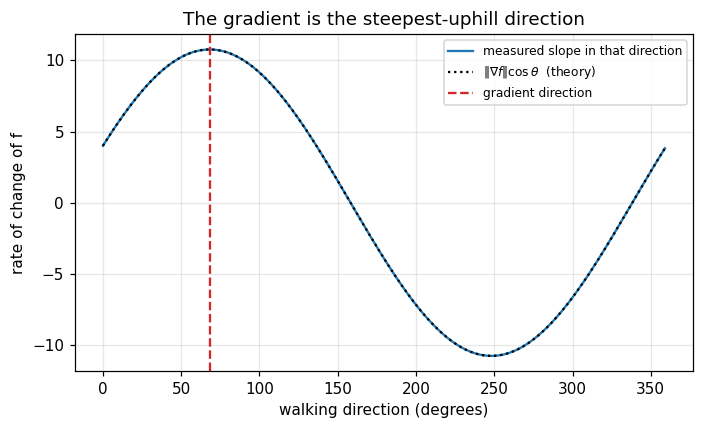

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(np.degrees(angles), slopes, label="measured slope in that direction")
ax.plot(np.degrees(angles), np.linalg.norm(g) * np.cos(angles - np.arctan2(g[1], g[0])), "k:",
        label=r"$\|\nabla f\|\cos\theta$  (theory)")
ax.axvline(np.degrees(np.arctan2(g[1], g[0])), color="tab:red", ls="--", label="gradient direction")
ax.set_xlabel("walking direction (degrees)"); ax.set_ylabel("rate of change of f")
ax.set_title("The gradient is the steepest-uphill direction"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "w2_steepest_direction.png", dpi=150); plt.show()

The measured curve sits exactly on $\|\nabla f\|\cos\theta$, peaking at the gradient's direction.

## 2. Gradient descent — walking downhill

$$\vec x_{t+1} = \vec x_t - \eta\,\nabla f(\vec x_t)$$

$\eta$ (eta) is the **learning rate**: how big a step to take. `mathkit.optim.gradient_descent` runs this loop and records every point it visits.

First a perfectly **round** bowl $f = x^2 + y^2$, then the **stretched** bowl $f = x^2 + 10y^2$ (steep in $y$, gentle in $x$) — real loss surfaces look much more like the stretched one.

round bowl       lr=0.1: final point [-0.0005  0.0003]  loss 2.87e-07
stretched bowl   lr=0.09: final point [-0.0012  0.0003]  loss 2.27e-06


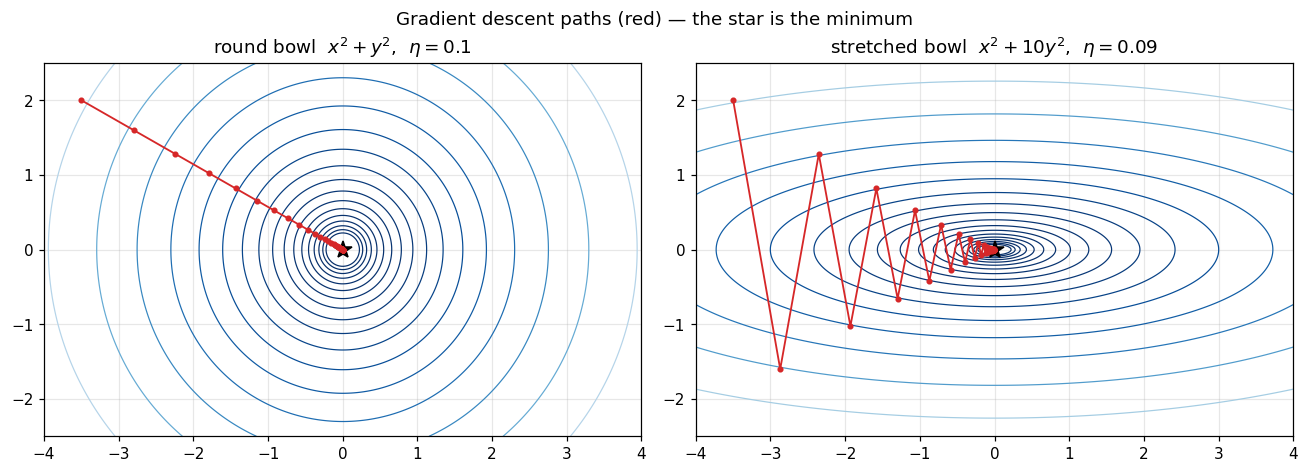

In [4]:
round_bowl = lambda v: v[0]**2 + v[1]**2
round_grad = lambda v: 2 * v

def contour_axes(ax, f, lim=(-4, 4, -2.5, 2.5)):
    xs, ys = np.meshgrid(np.linspace(lim[0], lim[1], 300), np.linspace(lim[2], lim[3], 300))
    zs = f(np.array([xs, ys]))
    ax.contour(xs, ys, zs, levels=np.geomspace(0.05, zs.max(), 18), cmap="Blues_r", linewidths=0.8)
    ax.plot(0, 0, "k*", ms=12)
    ax.set_aspect("equal"); ax.set_xlim(lim[0], lim[1]); ax.set_ylim(lim[2], lim[3])

start = [-3.5, 2.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, f, gf, title in [(axes[0], round_bowl, round_grad, r"round bowl  $x^2 + y^2$,  $\eta = 0.1$"),
                         (axes[1], bowl, bowl_grad, r"stretched bowl  $x^2 + 10y^2$,  $\eta = 0.09$")]:
    lr = 0.1 if f is round_bowl else 0.09
    run = gradient_descent(gf, start, lr=lr, n_steps=40, f=f)
    contour_axes(ax, f)
    ax.plot(run["path"][:, 0], run["path"][:, 1], "o-", color="tab:red", ms=3, lw=1.2)
    ax.set_title(title)
    name = "round bowl" if f is round_bowl else "stretched bowl"
    print(f"{name:<16s} lr={lr}: final point {run['path'][-1]}  loss {run['losses'][-1]:.2e}")
fig.suptitle("Gradient descent paths (red) — the star is the minimum")
fig.tight_layout(); fig.savefig(FIG / "w2_gd_paths.png", dpi=150); plt.show()

**Notice:** on the round bowl the gradient points straight at the minimum. On the stretched bowl it points **across** the valley (perpendicular to the contours, not toward the centre), so the path **zig-zags** in $y$ while creeping slowly in $x$. This zig-zag is the reason fancier optimisers (momentum, Adam — Week 20) exist.

## 3. Raise the learning rate until it explodes

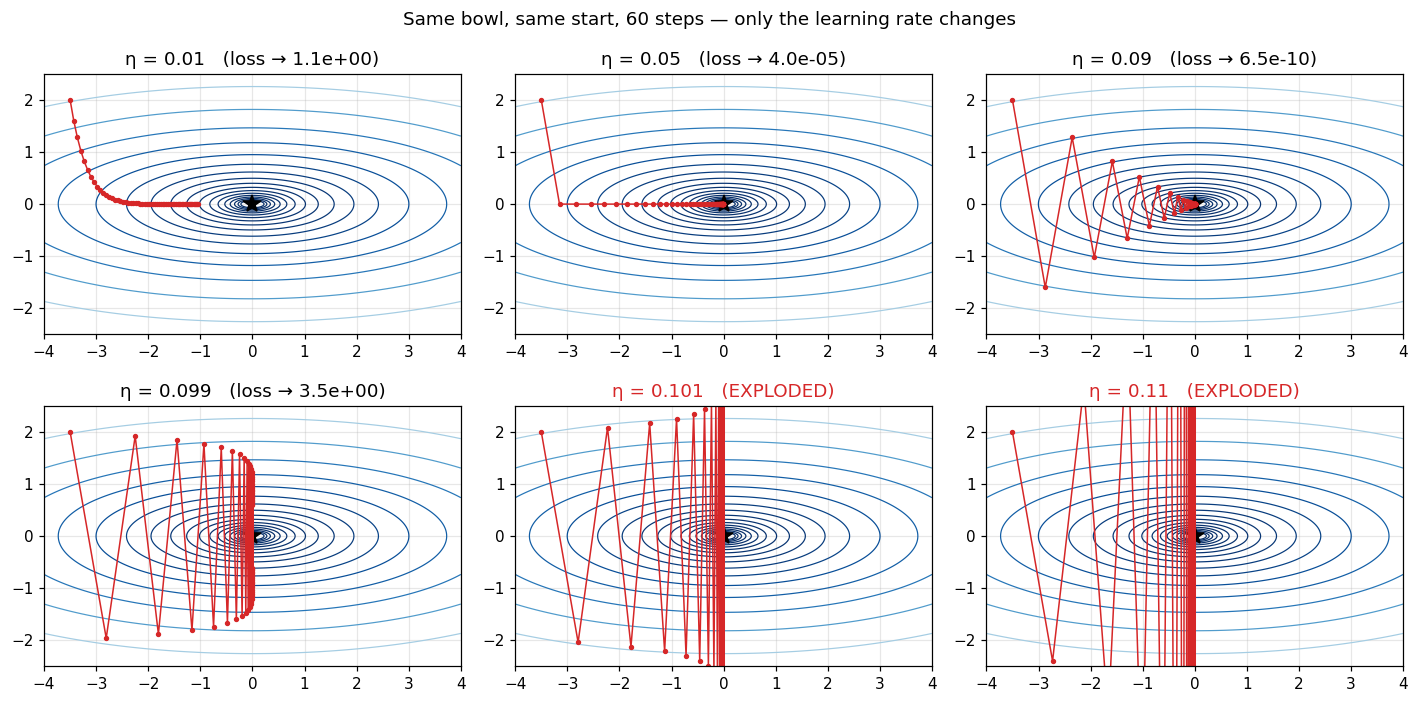

In [5]:
lrs = [0.01, 0.05, 0.09, 0.099, 0.101, 0.11]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
runs = {}
for ax, lr in zip(axes.flat, lrs):
    run = gradient_descent(bowl_grad, start, lr=lr, n_steps=60, f=bowl)
    runs[lr] = run
    contour_axes(ax, bowl)
    path = np.clip(run["path"], -50, 50)
    ax.plot(path[:, 0], path[:, 1], "o-", color="tab:red", ms=2.5, lw=1)
    verdict = "EXPLODED" if run["diverged"] or run["losses"][-1] > run["losses"][0] else f"loss → {run['losses'][-1]:.1e}"
    ax.set_title(f"η = {lr}   ({verdict})", color="tab:red" if "EXPL" in verdict else "black")
fig.suptitle("Same bowl, same start, 60 steps — only the learning rate changes")
fig.tight_layout(); fig.savefig(FIG / "w2_lr_sweep_paths.png", dpi=150); plt.show()

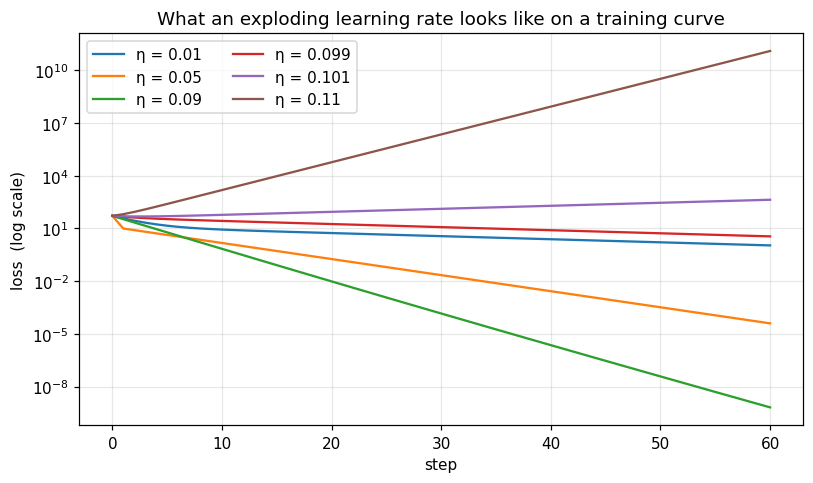

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for lr, run in runs.items():
    ax.semilogy(run["losses"], label=f"η = {lr}")
ax.set_xlabel("step"); ax.set_ylabel("loss  (log scale)")
ax.set_title("What an exploding learning rate looks like on a training curve")
ax.legend(ncol=2); fig.tight_layout(); fig.savefig(FIG / "w2_lr_sweep_loss.png", dpi=150); plt.show()

**Recognise this shape.** When a real model's loss curve goes *up* and then shoots to `inf`/`nan`, the first suspect is the learning rate. Also notice:

* $\eta = 0.01$: safe but slow — still far from the minimum after 60 steps.
* $\eta = 0.05$: $y$ is multiplied by $1 - 20(0.05) = 0$, so it hits the valley floor in **one** step, then walks straight along $x$.
* $\eta = 0.09$: $y$ is multiplied by $-0.8$ each step — it flips sign (the **zig-zag**) but shrinks, and $x$ moves fast. Best of the six.
* $\eta = 0.099$: $y$ is multiplied by $-0.98$ — it *barely* shrinks, so after 60 steps the loss is still high. Right at the edge, gradient descent is slow again.
* $\eta = 0.101$: the $y$ oscillation grows a little each step — slow-motion explosion.
* $\eta = 0.11$: explodes quickly.

## 4. Predicting the exact explosion point — eigenvalues

Why does it break between 0.099 and 0.101? Do it on paper. The update for $y$ alone is

$$y_{t+1} = y_t - \eta\cdot 20\,y_t = (1 - 20\eta)\,y_t$$

So each step multiplies $y$ by $(1-20\eta)$. It shrinks only if $|1 - 20\eta| < 1$, i.e. $0 < \eta < 0.1$. Likewise $x$ is multiplied by $(1 - 2\eta)$ each step, which is safe up to $\eta < 1$. **The steepest direction sets the limit.**

In general, the "steepness in each direction" of a bowl is measured by the **eigenvalues of the Hessian** (the matrix of second derivatives, 3Blue1Brown Calculus ch. 10):

$$H = \begin{bmatrix} \partial^2 f/\partial x^2 & \partial^2 f/\partial x\partial y \\ \partial^2 f/\partial y\partial x & \partial^2 f/\partial y^2 \end{bmatrix} = \begin{bmatrix} 2 & 0 \\ 0 & 20 \end{bmatrix}, \qquad \lambda_{\min} = 2,\;\lambda_{\max} = 20$$

$$\boxed{\text{gradient descent on a quadratic bowl is stable only if } \eta < \frac{2}{\lambda_{\max}}}$$

Here that is $2/20 = 0.1$ — exactly where it exploded. The ratio $\lambda_{\max}/\lambda_{\min} = 10$ (the **condition number**) measures how stretched the bowl is; the bigger it is, the more zig-zag and the slower the convergence.

Let's confirm with a **rotated** bowl, where you can't read the answer off the formula — you *need* the eigenvalues.

In [7]:
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
H = Q @ np.diag([1.0, 16.0]) @ Q.T          # a tilted, stretched bowl  f(v) = ½ vᵀ H v
f_rot = lambda v: 0.5 * v @ H @ v
g_rot = lambda v: H @ v                      # gradient of ½ vᵀ H v is H v (H symmetric)
gradient_check(f_rot, g_rot, [0.3, -1.1], verbose=True)

eigvals, eigvecs = np.linalg.eigh(H)
print("H =\n", H)
print("eigenvalues:", eigvals, " -> predicted explosion at η =", 2 / eigvals.max())

sweep = np.linspace(0.01, 0.2, 400)
final = []
for lr in sweep:
    r = gradient_descent(g_rot, [2.0, 1.0], lr=lr, n_steps=200, f=f_rot)
    final.append(r["losses"][-1] if not r["diverged"] else np.inf)
final = np.array(final)
first_bad = sweep[np.argmax(~np.isfinite(final) | (final > f_rot(np.array([2.0, 1.0]))))]
print(f"measured: first learning rate that fails ≈ {first_bad:.4f}")

[PASS] relative error = 4.032e-12  (tol = 1e-06)
H =
 [[ 4.75   -6.4952]
 [-6.4952 12.25  ]]
eigenvalues: [ 1. 16.]  -> predicted explosion at η = 0.125


measured: first learning rate that fails ≈ 0.1257


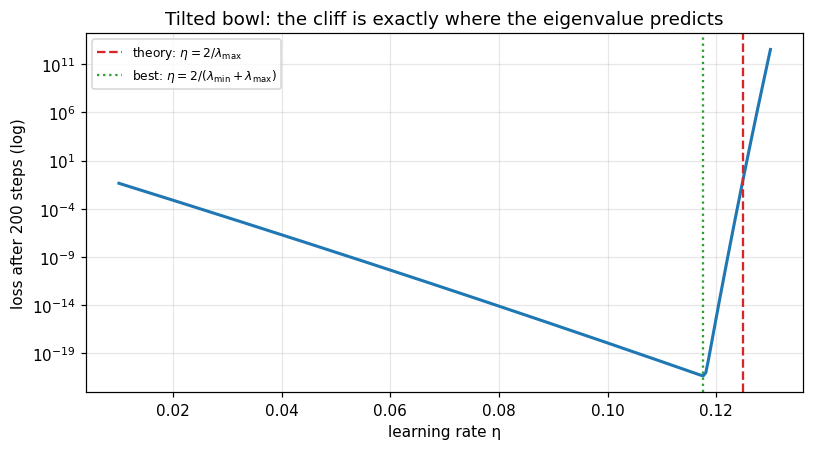

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(sweep, np.where(np.isfinite(final), final, np.nan), lw=2)
ax.axvline(2 / eigvals.max(), color="tab:red", ls="--", label=r"theory: $\eta = 2/\lambda_{\max}$")
ax.axvline(2 / (eigvals.min() + eigvals.max()), color="tab:green", ls=":",
           label=r"best: $\eta = 2/(\lambda_{\min}+\lambda_{\max})$")
ax.set_xlabel("learning rate η"); ax.set_ylabel("loss after 200 steps (log)")
ax.set_title("Tilted bowl: the cliff is exactly where the eigenvalue predicts")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / "w2_lr_cliff.png", dpi=150); plt.show()

The measured cliff lands on the red line (predicted 0.125, measured ≈ 0.126 on this grid).

**Bonus — the best learning rate is also predictable.** Each eigen-direction shrinks by a factor $|1-\eta\lambda|$ per step. The slow, gentle direction wants a *big* $\eta$; the steep direction wants $\eta$ near $1/\lambda_{\max}$. The best compromise makes the two factors equal: $1-\eta\lambda_{\min} = \eta\lambda_{\max}-1$, giving $\eta^* = 2/(\lambda_{\min}+\lambda_{\max}) = 2/17 \approx 0.118$ — exactly the bottom of the V in the plot (green line). Past it the steep direction starts to dominate and the loss after 200 steps rises until the cliff.

**This is the first time eigenvalues do real work for you:** they tell you the steepest direction of the loss surface, and that sets the largest safe step size. (In Week 16 eigenvectors come back as PCA.)

## 5. What to write in your lab notebook

1. The gradient points uphill because $D_{\vec u}f = \|\nabla f\|\cos\theta$ is largest at $\theta=0$.
2. Too small a learning rate → slow. Too large → oscillation, then explosion. The loss curve shape tells you which.
3. On a quadratic bowl the limit is $\eta < 2/\lambda_{\max}(H)$. Stretched bowls (big condition number) zig-zag.

## 6. Your turn

1. For $f(x,y) = 3x^2 + y^2$, predict on paper the learning rate at which gradient descent explodes. Then test it with `gradient_descent`.
2. Try a non-bowl function, e.g. $f(x, y) = (1-x)^2 + 100(y - x^2)^2$ (the Rosenbrock "banana"). Derive its gradient, *check it with the gradient checker*, and see how painfully slow plain gradient descent is.
3. **Explain out loud (Gate 1 Q5):** "Why does the gradient point uphill, and why do we step the other way?" — under 60 seconds, no notes.